In [19]:
### Chargement des librairies
library(ggplot2)
library(tidyverse)
library(gridExtra)
library(GGally)
library(plotly)
library(corrplot)
library(reshape2)
library(FactoMineR) 
library(factoextra)
library(glmnet) 
library(ggfortify)
library(pROC)
library(ROCR)

In [20]:
###Chargement et Affichage
path <- ""
data <- read.table(paste(path, "../divers/healthcare_synthetic_data.csv", sep = ""),
                    sep = ",", header = TRUE)

#head(data)

#summary(data)


In [21]:
###transfo des vars qualitatives en quantitatives et suppresion de la colonne Patient_ID
data[, "Heart_Disease_Risk"] <- as.factor(data[, "Heart_Disease_Risk"])
data[, "Gender"] <- as.factor(data[, "Gender"])
data[, "Smoking_Status"] <- as.factor(data[, "Smoking_Status"])
data[, "Alcohol_Consumption"] <- as.factor(data[, "Alcohol_Consumption"])
data[, "Physical_Activity_Level"] <- as.factor(data[, "Physical_Activity_Level"])
data[, "Family_History"] <- as.factor(data[, "Family_History"])
data$Patient_ID <- NULL
#summary(data)



In [22]:
###Création de 2 DataFrame dinstincts pour variables quantitatives et qualitatives  
data_quant <- select(data, where(is.numeric))
data_qual  <- select(data, !where(is.numeric))

summary(data_qual)
summary(data_quant)
###création des colonnes contenant les noms des vars qualitatives et quantitatives
vars_quant <- names(data)[sapply(data, is.numeric)]
vars_qual <- names(data)[sapply(data, function(x) !is.numeric(x))]



 Gender   Smoking_Status Alcohol_Consumption Physical_Activity_Level
 0:7622   0:10495        0:7502              0:3020                 
 1:7378   1: 4505        1:5939              1:6009                 
                         2:1559              2:4453                 
                                             3:1518                 
 Family_History Heart_Disease_Risk
 0:12757        0:8460            
 1: 2243        1:6540            
                                  
                                  

      Age          Height_cm       Weight_kg           BMI       
 Min.   :25.00   Min.   :138.5   Min.   : 33.70   Min.   :14.50  
 1st Qu.:46.00   1st Qu.:158.5   1st Qu.: 65.20   1st Qu.:24.50  
 Median :55.00   Median :164.7   Median : 73.90   Median :27.20  
 Mean   :54.54   Mean   :165.3   Mean   : 75.25   Mean   :27.45  
 3rd Qu.:63.00   3rd Qu.:172.0   3rd Qu.: 83.90   3rd Qu.:30.00  
 Max.   :85.00   Max.   :198.1   Max.   :150.10   Max.   :46.10  
  Systolic_BP     Diastolic_BP    Cholesterol_Total Cholesterol_LDL
 Min.   : 90.0   Min.   : 60.00   Min.   :127.0     Min.   : 70.0  
 1st Qu.:127.0   1st Qu.: 85.00   1st Qu.:201.0     1st Qu.:128.0  
 Median :135.0   Median : 91.00   Median :216.0     Median :140.0  
 Mean   :135.1   Mean   : 90.54   Mean   :216.2     Mean   :140.4  
 3rd Qu.:143.0   3rd Qu.: 96.00   3rd Qu.:231.0     3rd Qu.:152.0  
 Max.   :182.0   Max.   :120.00   Max.   :303.0     Max.   :210.0  
 Cholesterol_HDL Fasting_Blood_Sugar  Stress_Level     Sleep_H

In [23]:
# Vérification des valeurs manquantes par colonne
missing_values <- colSums(is.na(data))
print("Valeurs manquantes par colonne :")
print(missing_values)

# Vérification des doublons
print(paste("Nombre de lignes en double :", sum(duplicated(data))))

[1] "Valeurs manquantes par colonne :"
                    Age                  Gender               Height_cm 
                      0                       0                       0 
              Weight_kg                     BMI             Systolic_BP 
                      0                       0                       0 
           Diastolic_BP       Cholesterol_Total         Cholesterol_LDL 
                      0                       0                       0 
        Cholesterol_HDL     Fasting_Blood_Sugar          Smoking_Status 
                      0                       0                       0 
    Alcohol_Consumption Physical_Activity_Level          Family_History 
                      0                       0                       0 
           Stress_Level             Sleep_Hours      Heart_Disease_Risk 
                      0                       0                       0 


[1] "Nombre de lignes en double : 0"


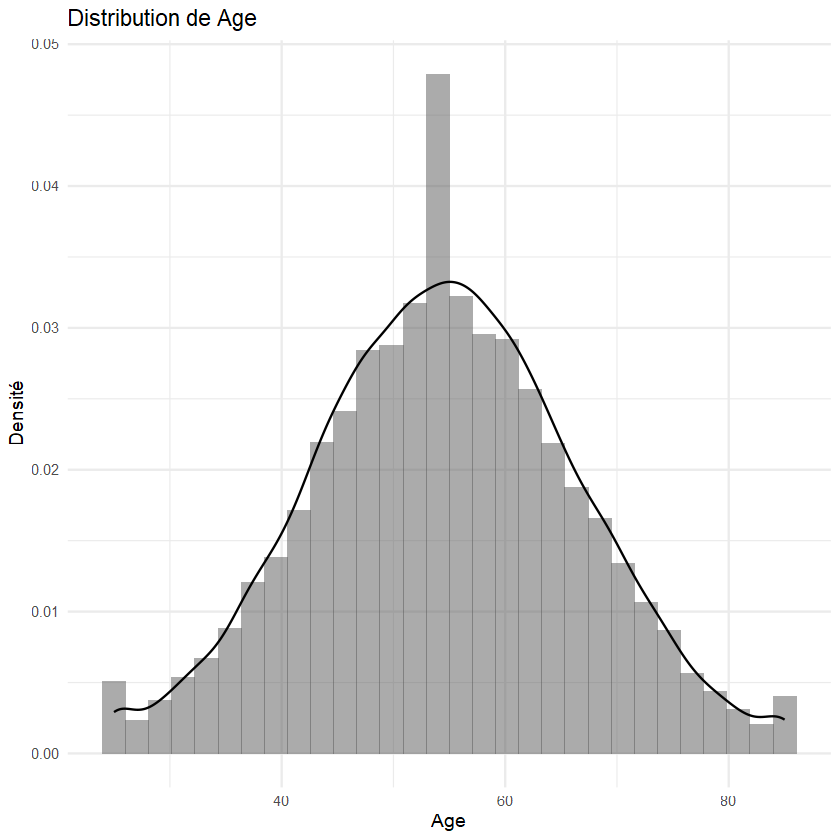

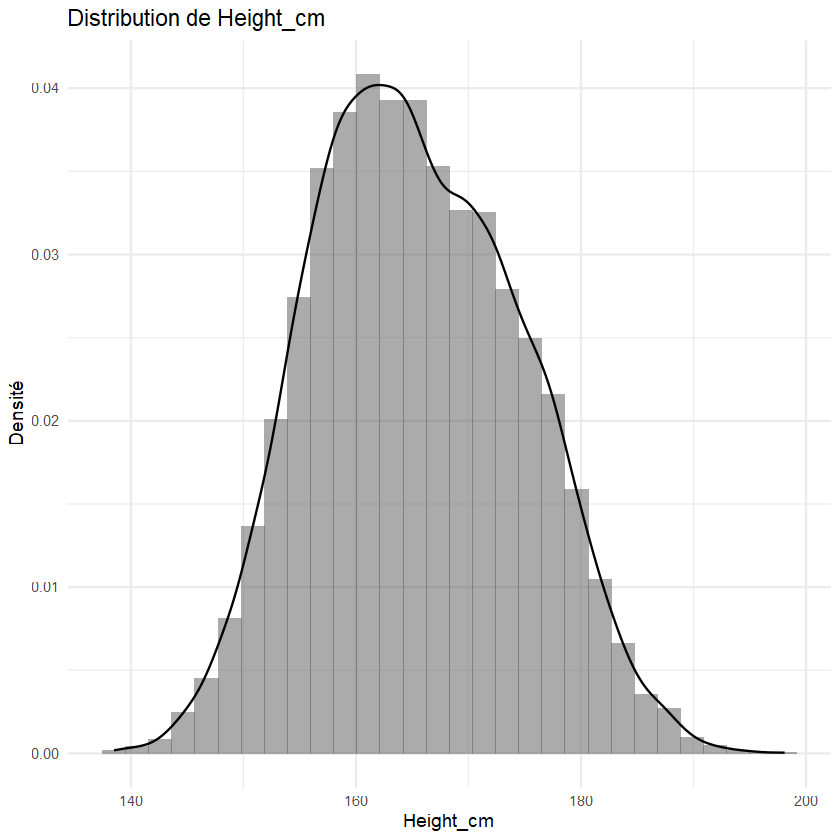

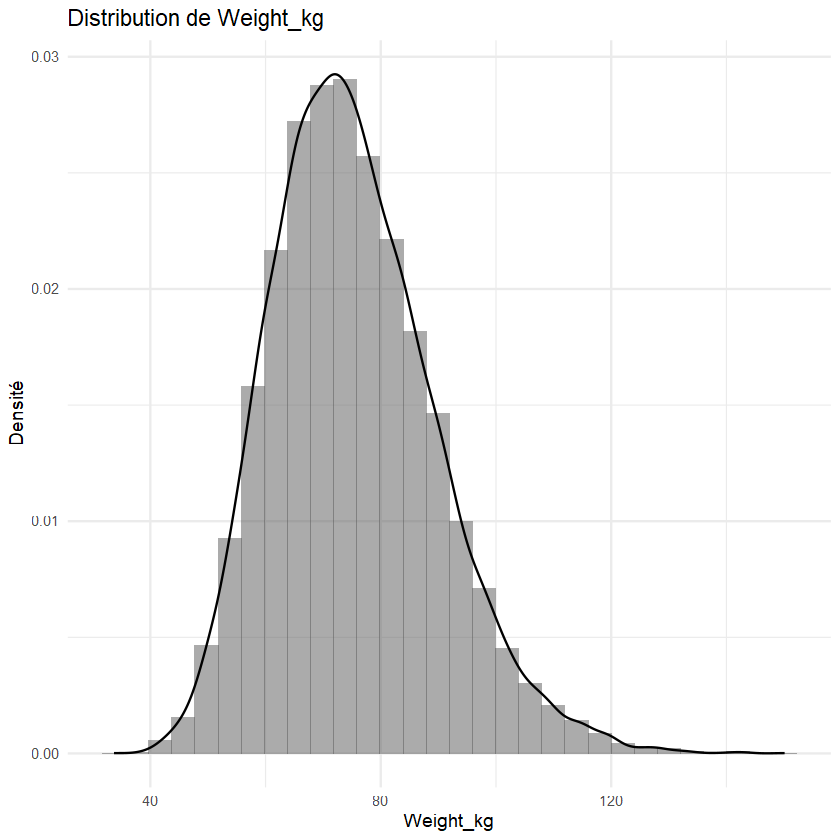

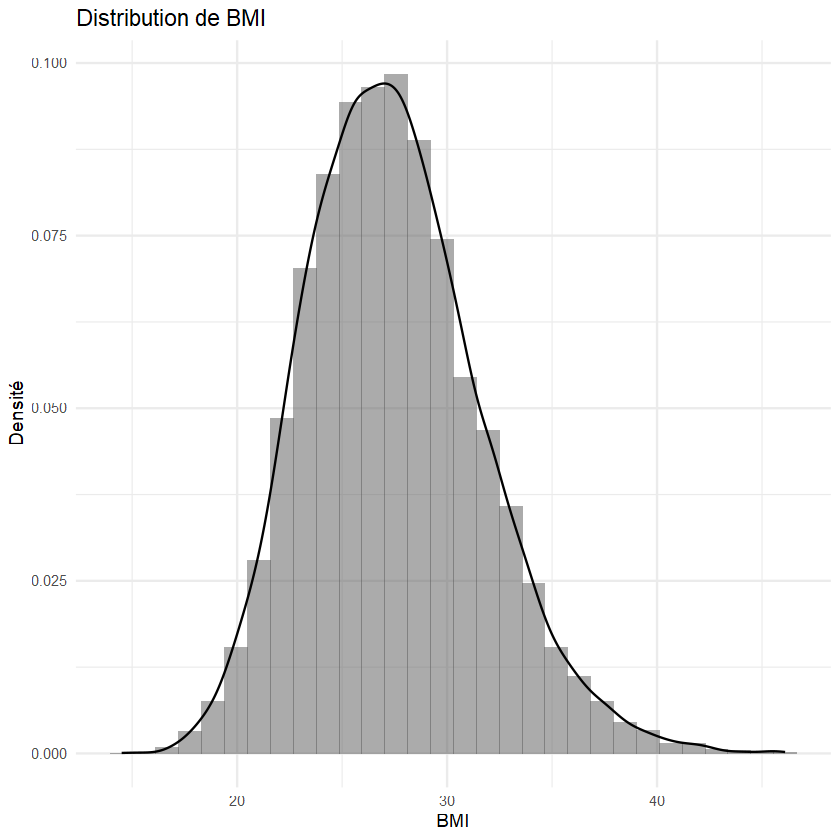

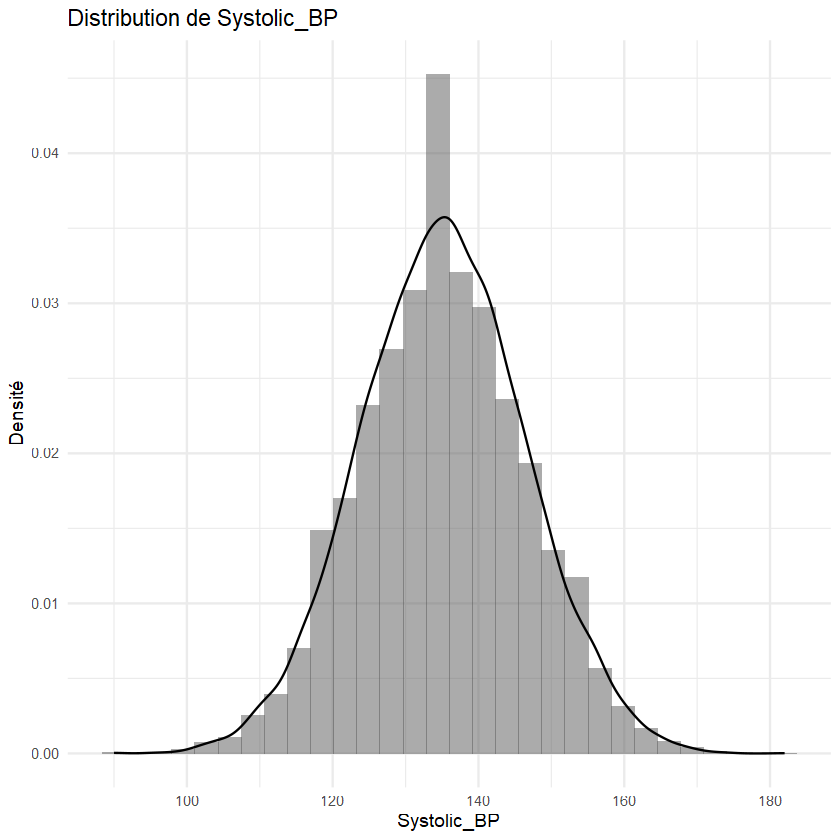

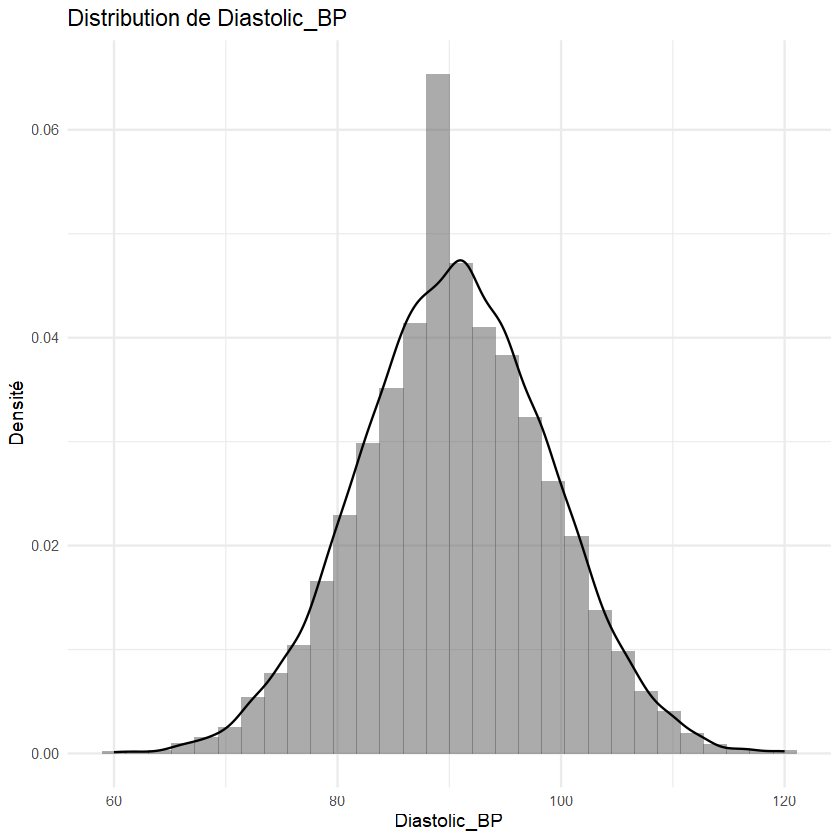

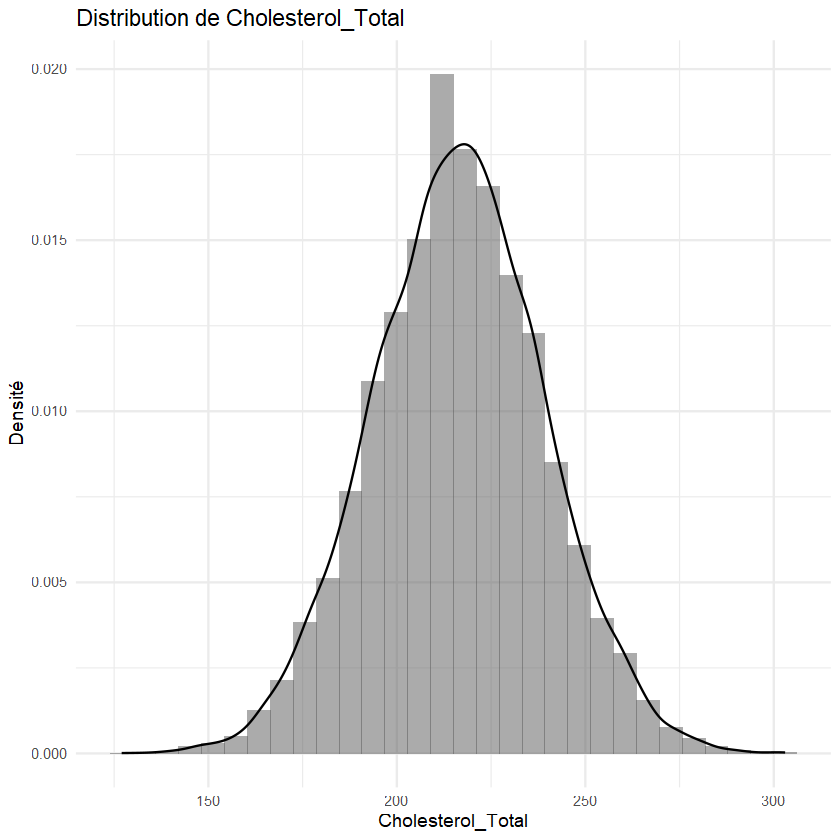

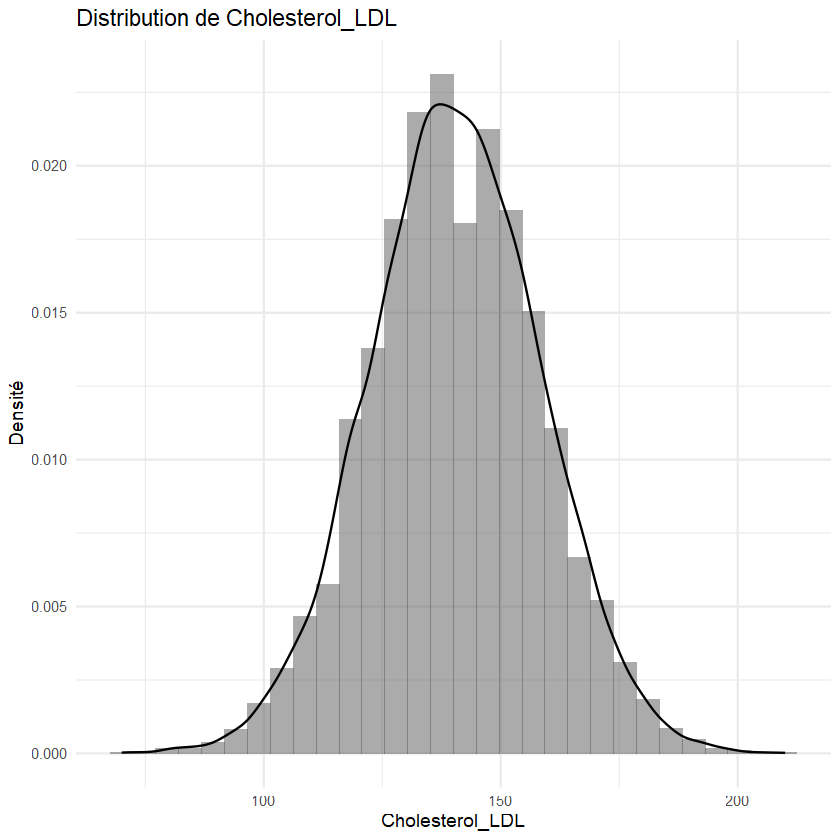

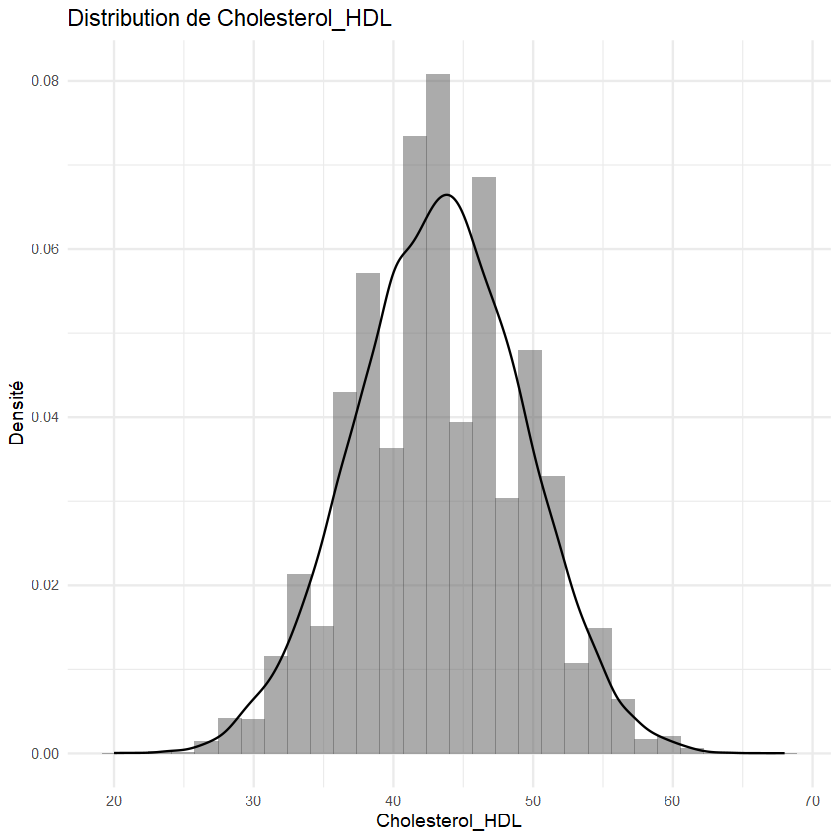

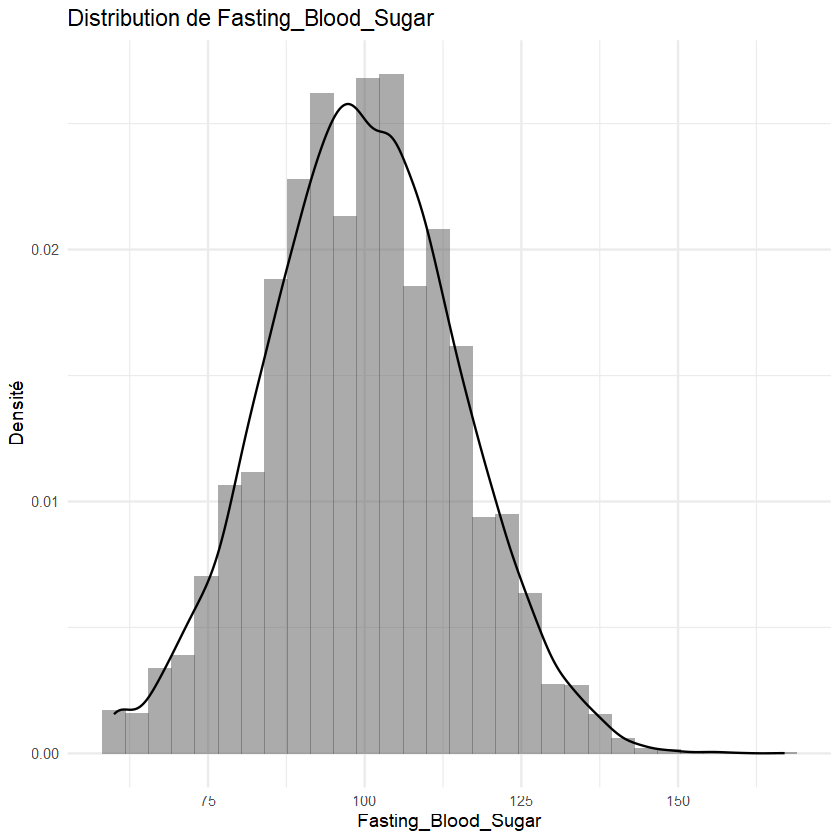

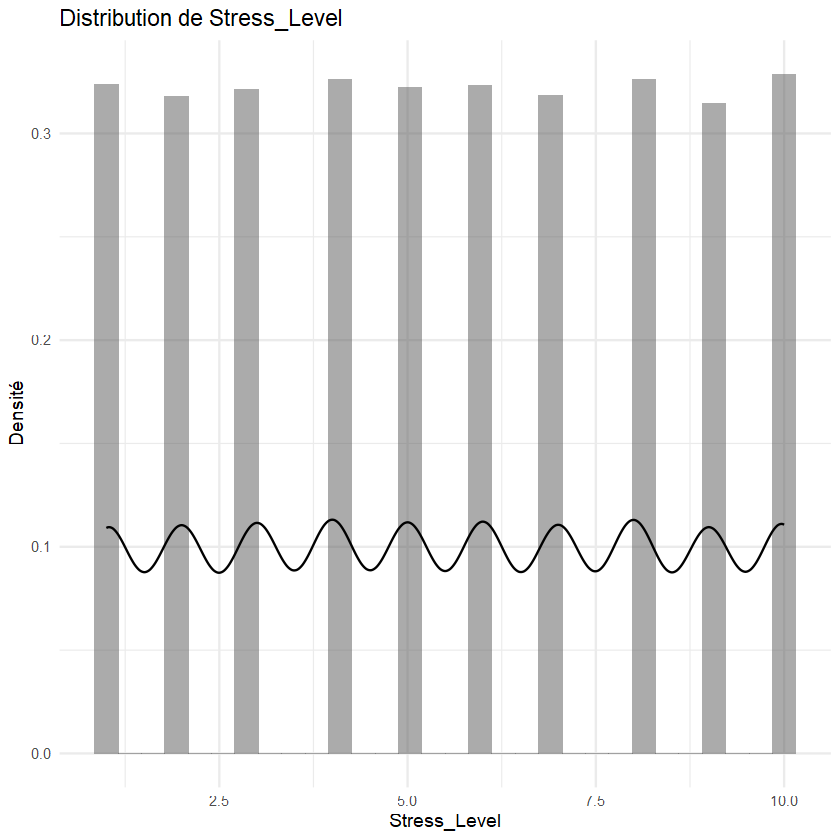

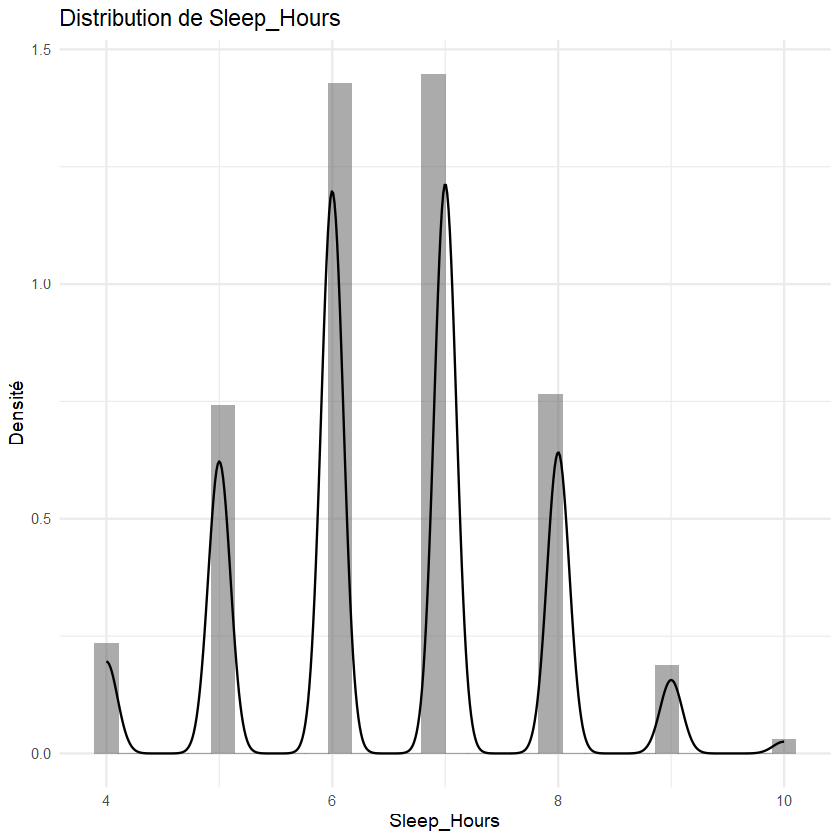

In [24]:
###fonction générant histogramme montrant distribution de Var_X 
histo_compare <- function(var_name) {
    g<-ggplot(data, aes(x = .data[[var_name]])) +
    geom_histogram(aes(y = after_stat(density)), 
                   bins = 30, 
                   alpha = 0.5, 
                   position = "identity") +
    geom_density(alpha = 0.2) +
    theme_minimal() +
    labs(title = paste("Distribution de", var_name),
         x = var_name,
         y = "Densité") 
    return(g)
}
for (v in vars_quant) {
  p <- histo_compare(v)
  print(p) 
}



Transformations pour obtenir des distributions plus symétriques et ainsi plus "gaussiennes".

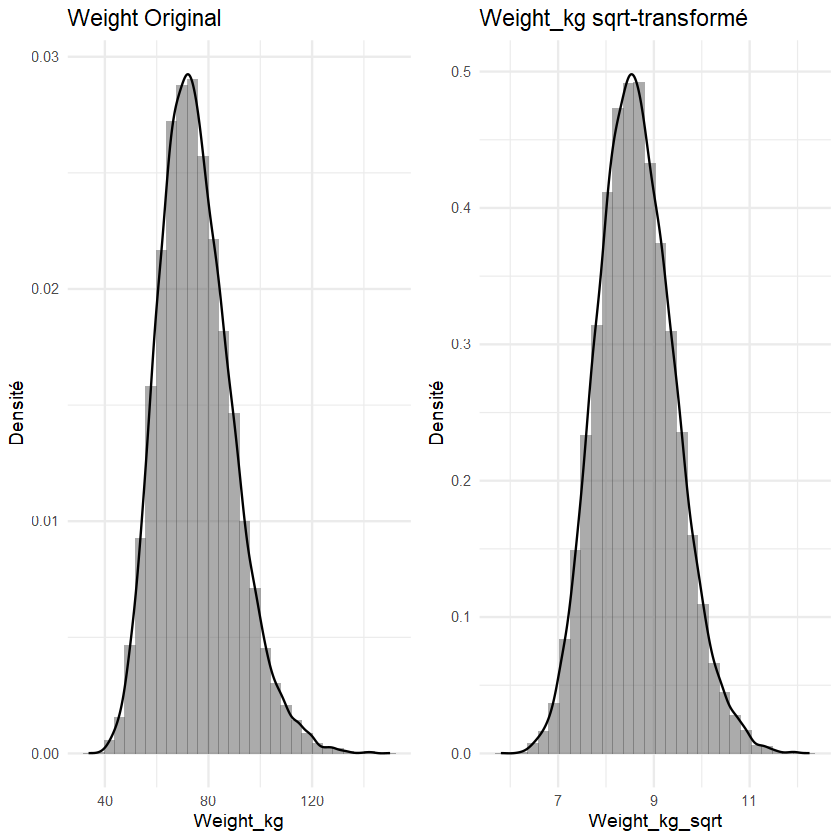

[1] "Age"                      "Gender"                  
 [3] "Height_cm"                "Weight_kg"               
 [5] "BMI"                      "Systolic_BP"             
 [7] "Diastolic_BP"             "Cholesterol_Total"       
 [9] "Cholesterol_LDL"          "Cholesterol_HDL"         
[11] "Fasting_Blood_Sugar"      "Smoking_Status"          
[13] "Alcohol_Consumption"      "Physical_Activity_Level" 
[15] "Family_History"           "Stress_Level"            
[17] "Sleep_Hours"              "Heart_Disease_Risk"      
[19] "Weight_kg_sqrt"           "Fasting_Blood_Sugar_sqrt"

[1] "Age"                      "Gender"                  
 [3] "Height_cm"                "BMI"                     
 [5] "Systolic_BP"              "Diastolic_BP"            
 [7] "Cholesterol_Total"        "Cholesterol_LDL"         
 [9] "Cholesterol_HDL"          "Smoking_Status"          
[11] "Alcohol_Consumption"      "Physical_Activity_Level" 
[13] "Family_History"           "Stress_Level"            
[15] "Sleep_Hours"              "Heart_Disease_Risk"      
[17] "Weight_kg_sqrt"           "Fasting_Blood_Sugar_sqrt"

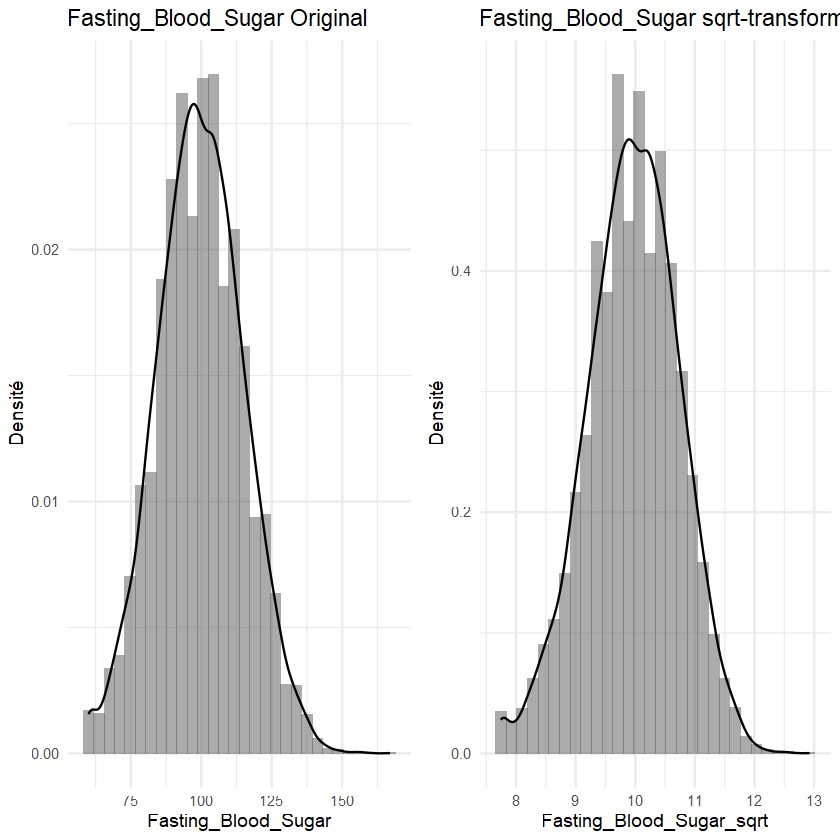

In [25]:
# Test de transformation 1 
data$Weight_kg_sqrt <- sqrt(data$Weight_kg)

p1 <- histo_compare("Weight_kg") + labs(title = "Weight Original")
p2 <- histo_compare("Weight_kg_sqrt") + labs(title = "Weight_kg sqrt-transformé") 

grid.arrange(p1, p2, ncol = 2)

# Test de transformation 2
data$Fasting_Blood_Sugar_sqrt <- sqrt(data$Fasting_Blood_Sugar)

p1 <- histo_compare("Fasting_Blood_Sugar") + labs(title = "Fasting_Blood_Sugar Original")
p2 <- histo_compare("Fasting_Blood_Sugar_sqrt") + labs(title = "Fasting_Blood_Sugar sqrt-transformé") 

grid.arrange(p1, p2, ncol = 2)
names(data)
data <- data[, c(1:3,5:10,12:20)]
names(data)
###pas sur de l'utilité des transfos



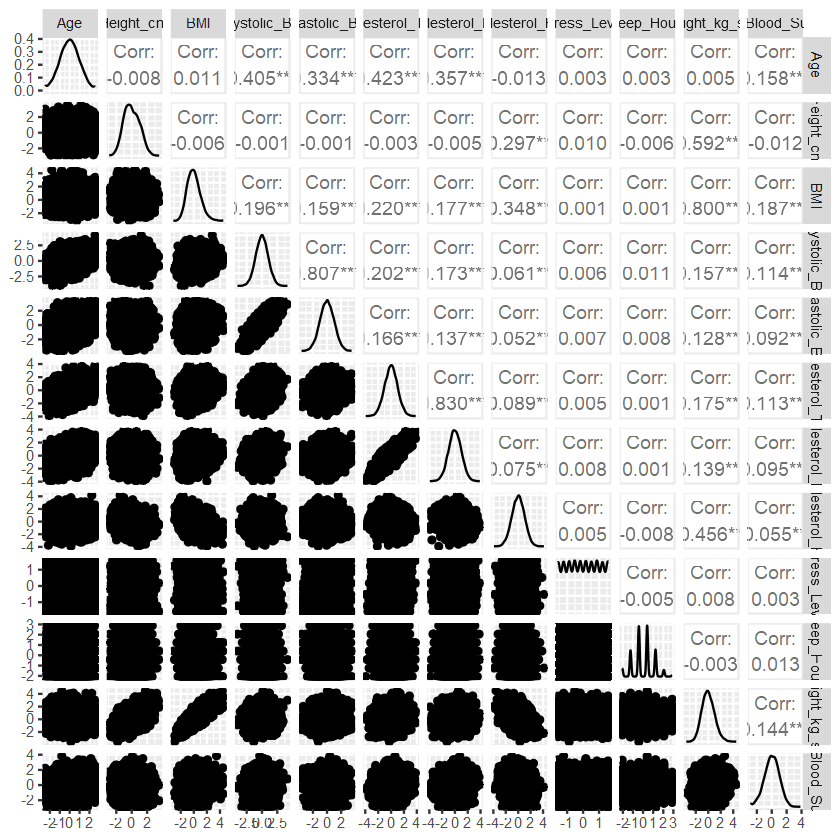

In [26]:
###Création de 2 DataFrame dinstincts pour variables quantitatives et qualitatives  
data_quant <- select(data, where(is.numeric))

data_standardisees <- scale(data_quant, center = TRUE, scale = TRUE)
ggpairs(data_standardisees)


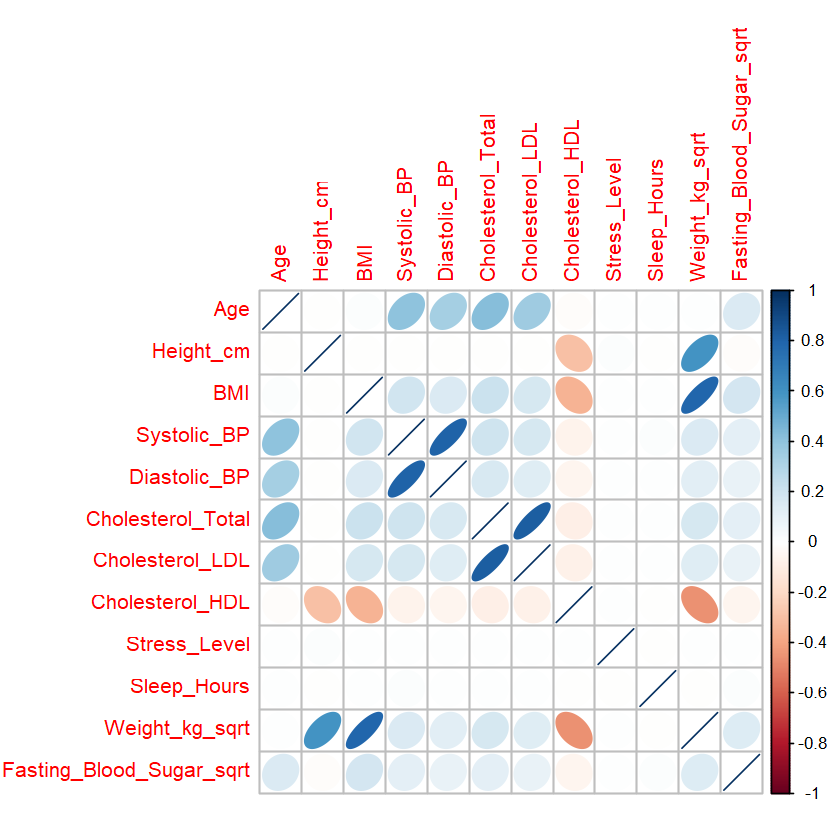

In [27]:
library(corrplot)
corrplot(cor(data_quant),method="ellipse")

Warning message:
"The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(count)` instead."


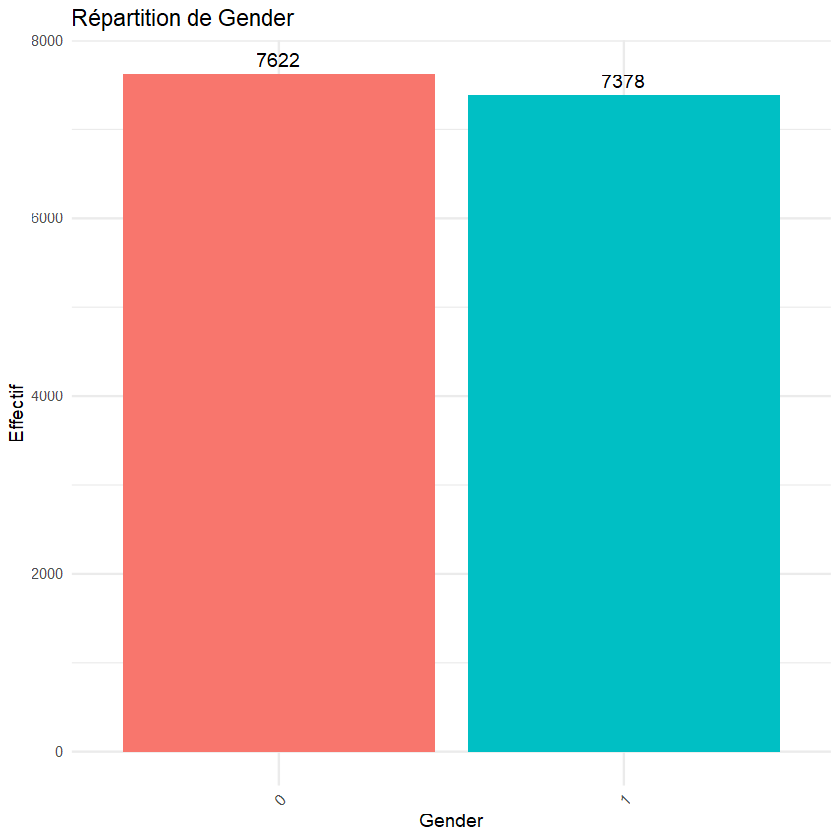

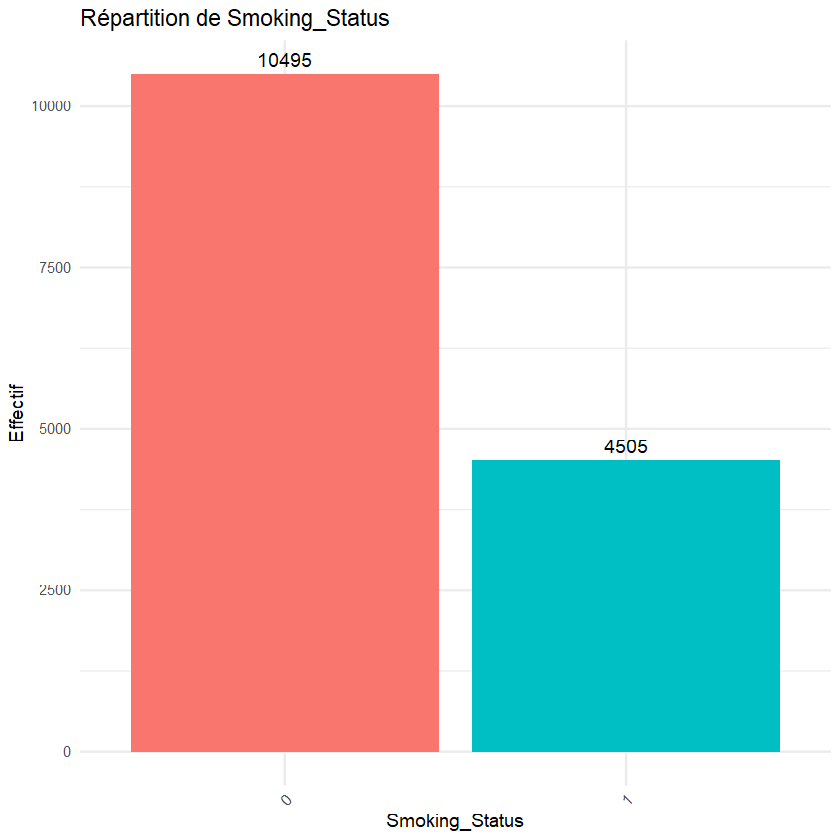

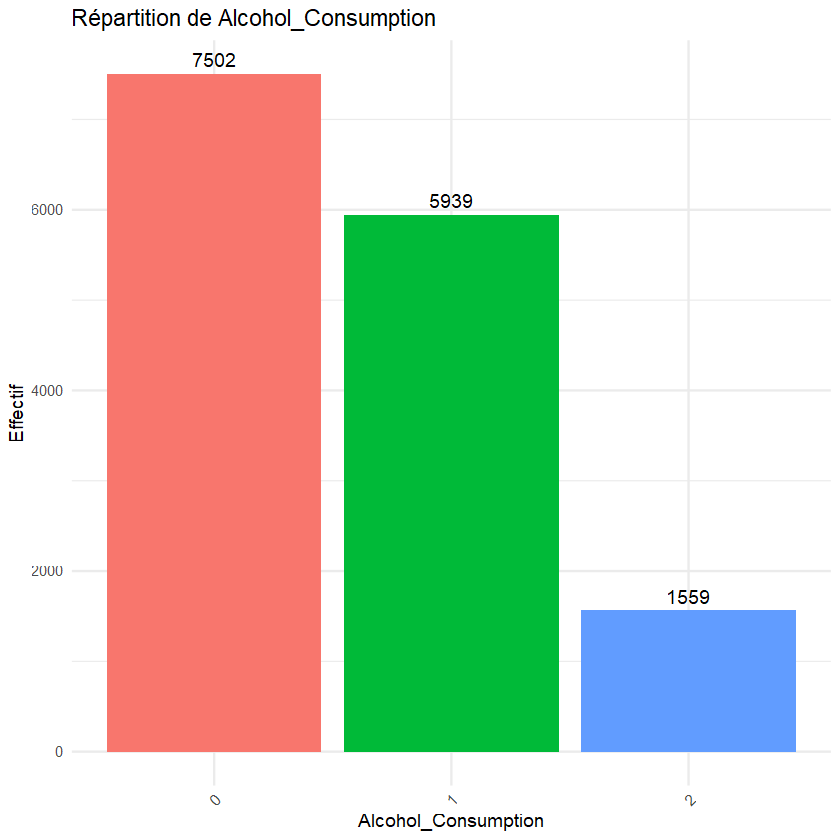

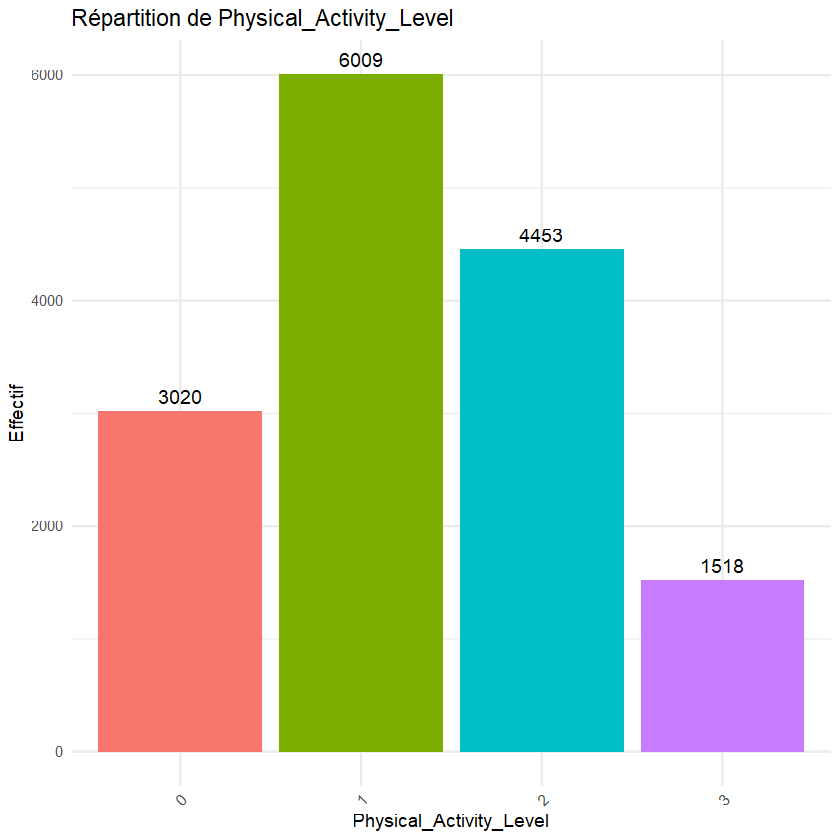

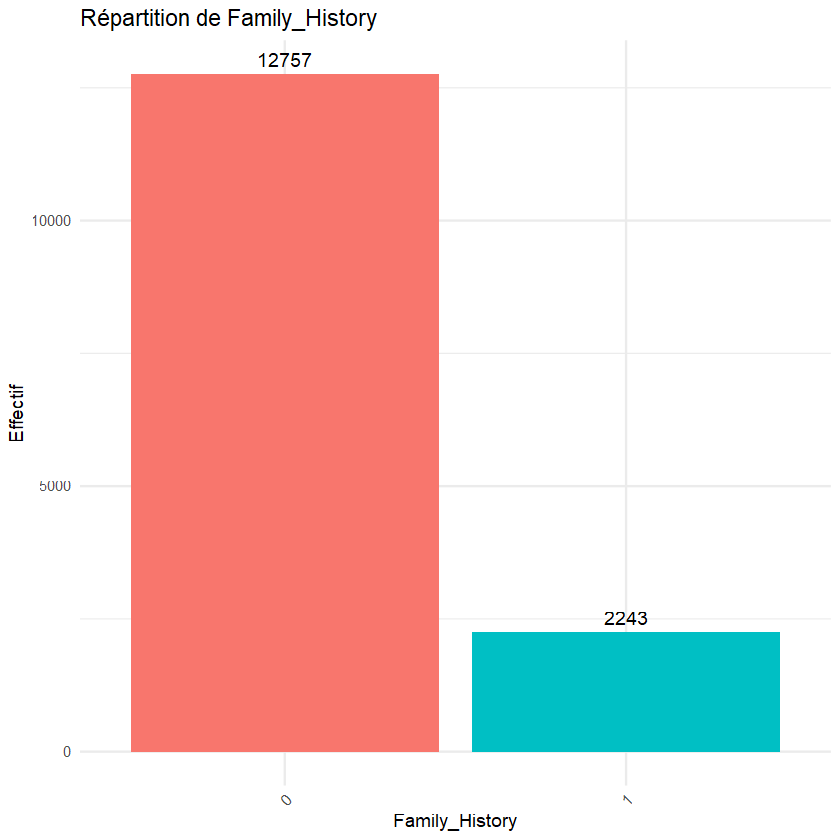

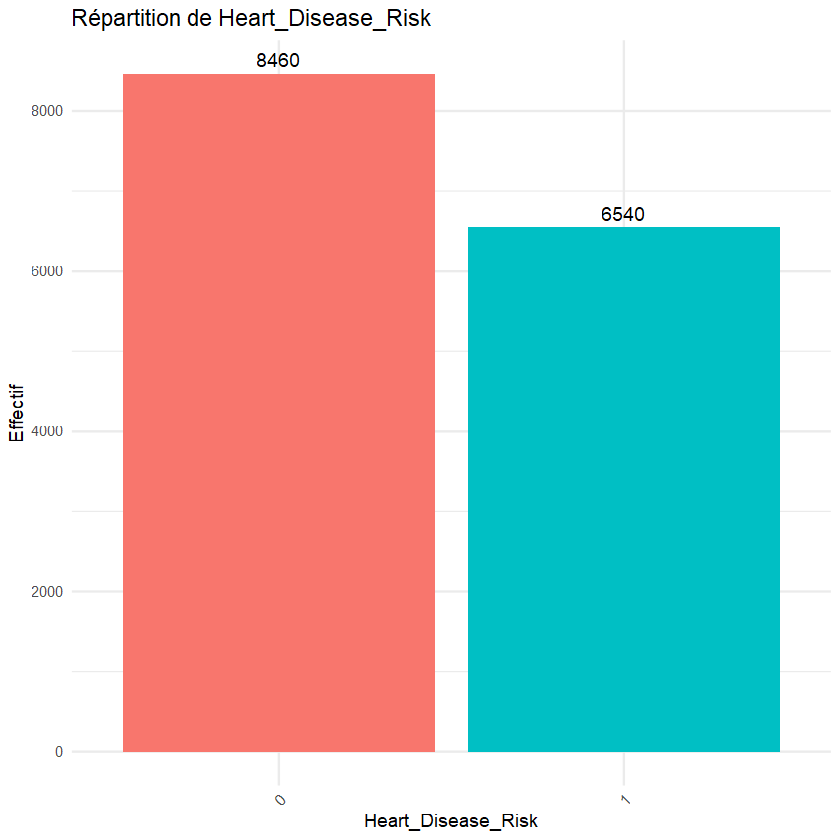

In [28]:
# Fonction générant un barplot montrant la distribution de Var_X
bar_compare <- function(var_name) {
    g <- ggplot(data, aes(x = .data[[var_name]], fill = .data[[var_name]])) +
        geom_bar() +                                # Compte les effectifs par modalité
        geom_text(stat='count', aes(label=..count..), vjust=-0.5) + # Ajoute les effectifs au-dessus
        theme_minimal() +
        theme(axis.text.x = element_text(angle = 45, hjust = 1)) + # Incline les labels si longs
        labs(title = paste("Répartition de", var_name),
             x = var_name,
             y = "Effectif") +
        guides(fill = "none") # Enlever la légende si elle est redondante avec l'axe X
    
    return(g)
}

# Boucle sur vos variables qualitatives
# (Assurez-vous que vars_qual contient les noms de vos colonnes facteurs)
for (v in vars_qual) {
    p <- bar_compare(v)
    print(p)
}

Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


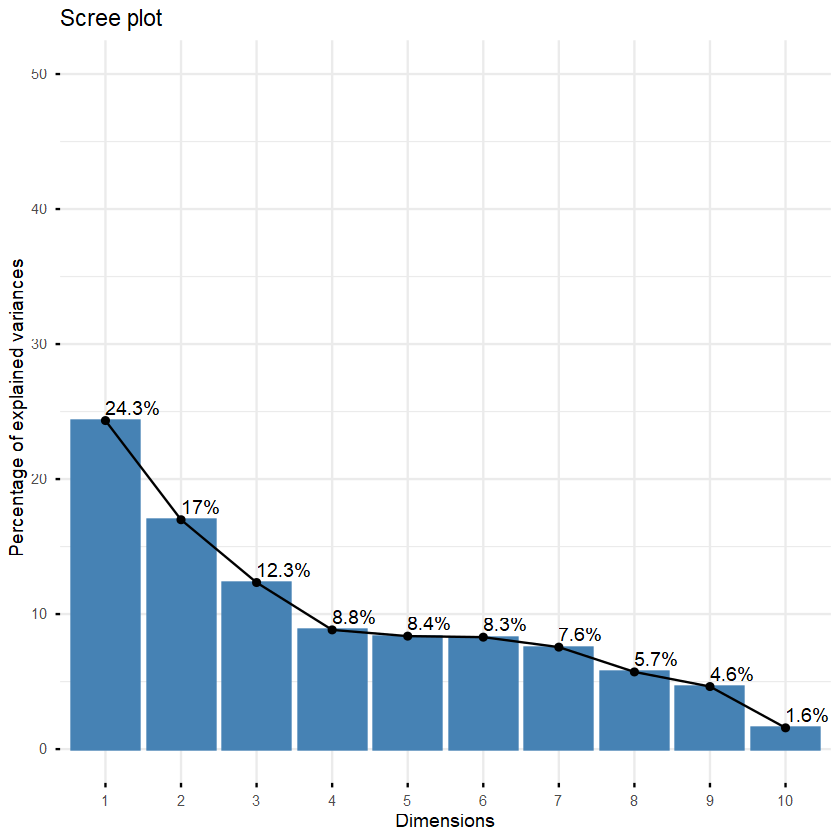

Ignoring unknown labels:
• linetype : "Risque"


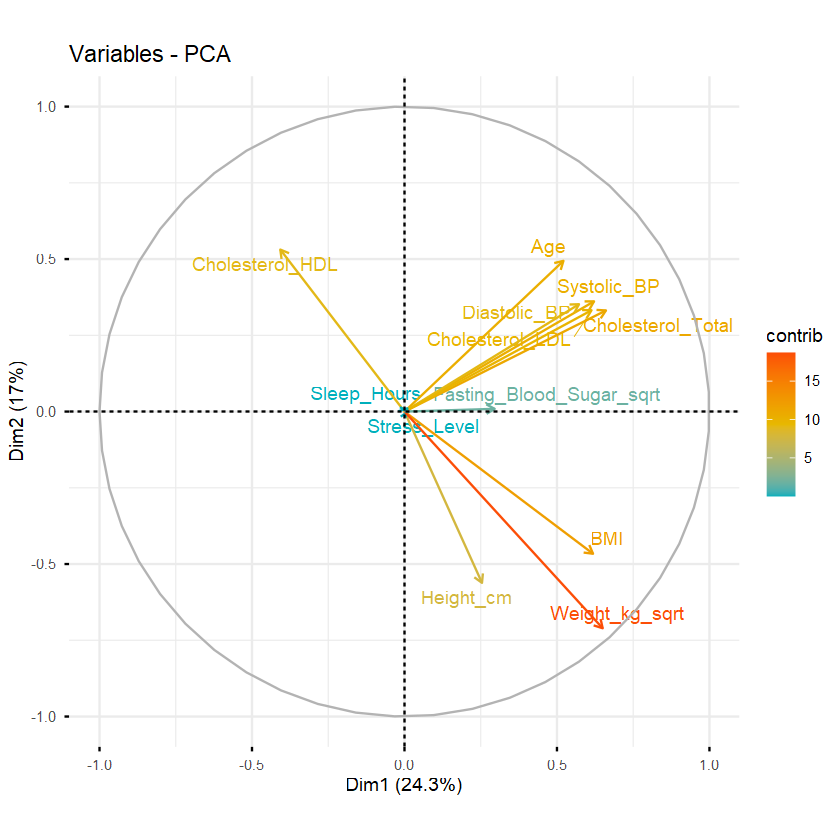

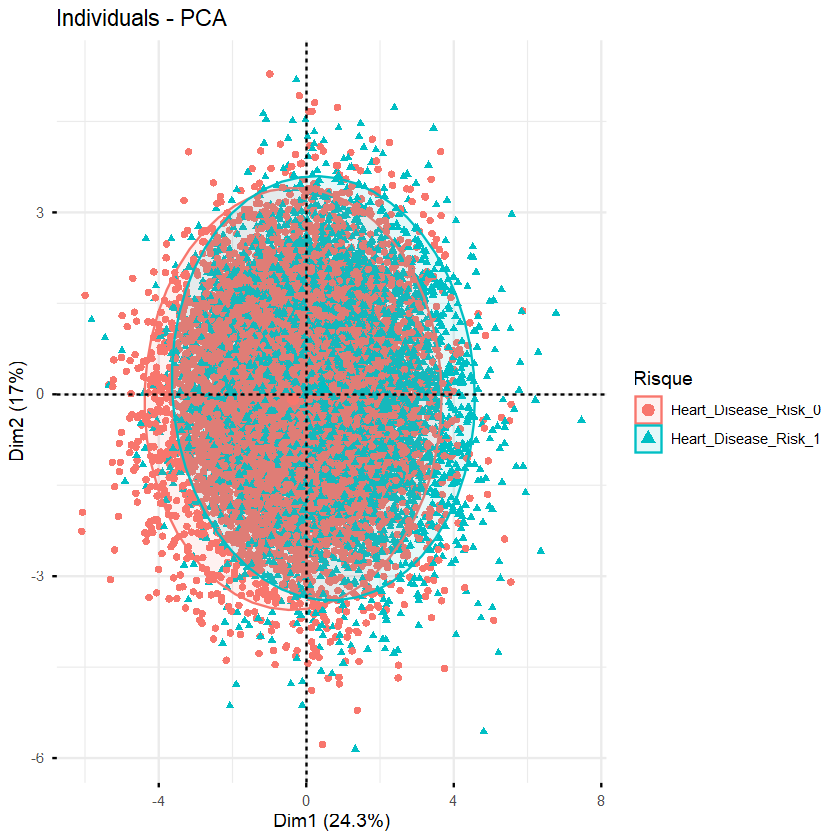

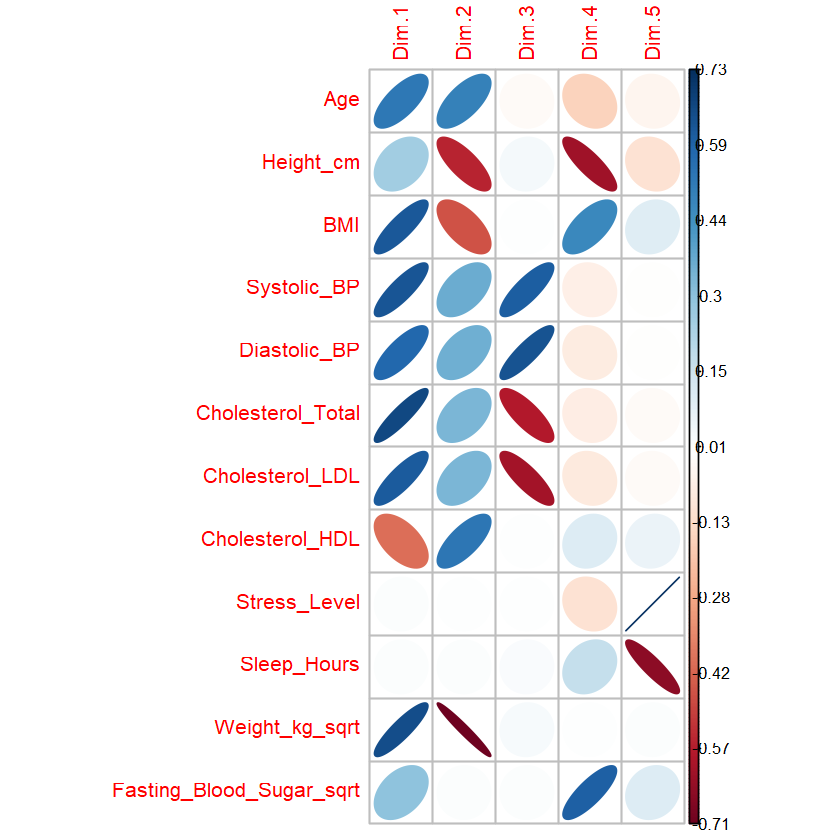

In [32]:
# On crée un jeu de données dédié à l'ACP
# On combine les variables quantitatives ET la cible (Heart_Disease_Risk)
data_acp <- cbind(data_quant, Heart_Disease_Risk = data$Heart_Disease_Risk)

# L'ACP : 
# scale.unit = TRUE (normalise les données automatiquement)
# quali.sup = ncol(data_acp) (dit à R que la dernière colonne est qualitative et ne doit pas servir au calcul)
res_acp <- PCA(data_acp, scale.unit = TRUE, graph = FALSE, quali.sup = ncol(data_acp))

# A. Eboulis des valeurs propres (Combien d'axes garder ?)
fviz_eig(res_acp, addlabels = TRUE, ylim = c(0, 50))

# B. Cercle des corrélations (Quelles variables numériques sont liées ?)
# Cela montrera par exemple si l'IMC et le Poids sont très proches
fviz_pca_var(res_acp, col.var = "contrib", 
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             repel = TRUE)

# C. Graphique des individus (Le plus important pour votre projet)
# On colorie les points selon le risque de maladie cardiaque
fviz_pca_ind(res_acp, 
             geom.ind = "point", 
             habillage = ncol(data_acp), # Utilise la variable qualitative (la cible)
             addEllipses = TRUE,        # Trace des cercles autour des groupes
             legend.title = "Risque")

corrplot(res_acp$var$cor, is.corr=FALSE,method="ellipse")

In [30]:
#Identifier les colonnes numériques (en excluant la cible)
vars_quant <- names(data)[sapply(data, is.numeric)]

#Appliquer la normalisation (Z-score scaling)
data_scaled <- data
data_scaled[vars_quant] <- scale(data[vars_quant])

# Vérification
summary(data_scaled[vars_quant]) # La moyenne (Mean) doit être proche de 0

      Age             Height_cm             BMI            Systolic_BP      
 Min.   :-2.48736   Min.   :-2.92139   Min.   :-3.13089   Min.   :-4.00667  
 1st Qu.:-0.71898   1st Qu.:-0.74423   1st Qu.:-0.71248   1st Qu.:-0.72089  
 Median : 0.03889   Median :-0.06932   Median :-0.05951   Median :-0.01045  
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.71256   3rd Qu.: 0.72534   3rd Qu.: 0.61764   3rd Qu.: 0.69999  
 Max.   : 2.56515   Max.   : 3.56653   Max.   : 4.51128   Max.   : 4.16338  
  Diastolic_BP      Cholesterol_Total  Cholesterol_LDL    Cholesterol_HDL   
 Min.   :-3.61731   Min.   :-3.93298   Min.   :-3.92737   Min.   :-3.90865  
 1st Qu.:-0.65631   1st Qu.:-0.67195   1st Qu.:-0.68970   1st Qu.:-0.72241  
 Median : 0.05433   Median :-0.01093   Median :-0.01983   Median :-0.05163  
 Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000   Mean   : 0.00000  
 3rd Qu.: 0.64653   3rd Qu.: 0.65009   3rd Qu.: 0.65003   3rd Qu.: 0.61916  